# IMDb Top 250

*Get all 250 movies from the IMDb Top 250 chart with their rating, votes, genre, content rating and duration*

In [13]:
import requests
from bs4 import BeautifulSoup

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36"
}
response = requests.get("https://www.imdb.com/chart/top/", headers=headers)
html = response.text
soup = BeautifulSoup(html, "html.parser")
all_titles = soup.find_all("h3", attrs={"class": "ipc-title__text"})
movies = []
for title in all_titles:
    title_string = title.get_text()
    if title_string[0].isdigit():
        movies.append(title_string.split(". ", 1)[1])

print(response.status_code, len(movies))
print(movies[:5])

202 0
[]


**Blocked before getting any data.** requests returned status 202 and 0 movies even with a browser User-Agent. 202 means "accepted", not an error, so I checked the response more closely below.

In [14]:
print("page length:", len(response.text))
for key, value in response.headers.items():
    print(key, ":", value)

page length: 0
Content-Type : text/html; charset=UTF-8
Content-Length : 0
Connection : keep-alive
Server : Server
Date : Fri, 09 Oct 2026 03:49:43 GMT
Vary : User-Agent,Accept-Encoding
x-amzn-waf-action : challenge
Cache-Control : no-store, max-age=0
Access-Control-Allow-Origin : *
Access-Control-Max-Age : 86400
Access-Control-Allow-Methods : OPTIONS,GET,POST
Access-Control-Expose-Headers : x-amzn-waf-action
x-amz-rid : Y9FQGSWKZETFFX6FNECM
Strict-Transport-Security : max-age=47474747; includeSubDomains; preload
Edge-Cache-Control : no-store,no-cache,stale-if-error=0,stale-while-revalidate=0
X-Cache : Miss from cloudfront
Via : 1.1 2b2491fc3c8b84a7fd8dd41a09ba5510.cloudfront.net (CloudFront)
X-Amz-Cf-Pop : BOS50-P4
Alt-Svc : h3=":443"; ma=86400
X-Amz-Cf-Id : PE6aoy-Mu2-durjgu0NjgdJw26F8PgMxcJrnP0PbPPtXkOVwQWviNQ==


**The response is empty.** both the page length and the `Content-Length` header are 0, so the server sent nothing to parse. Among the response headers there is `x-amzn-waf-action: challenge`. Searching that name showed it comes from AWS WAF (Amazon's firewall), and "challenge" means the visitor has to pass a check before getting the real page. The other headers (`x-amz-rid`, CloudFront) also show the request went through Amazon's servers. requests can't pass a check like this, so I switched to Selenium, which runs a real browser.

In [15]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

options = webdriver.ChromeOptions()
options.add_argument("--lang=en-US")
driver = webdriver.Chrome(options=options)

try:
    driver.get("https://www.imdb.com/chart/top/")
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "h3.ipc-title__text"))
    )
    html = driver.page_source
finally:
    driver.quit()

soup = BeautifulSoup(html, "html.parser")
movies = []
for title in soup.find_all("h3", attrs={"class": "ipc-title__text"}):
    title_string = title.get_text()
    if title_string[0].isdigit():
        movies.append(title_string.split(". ", 1)[1])

print(len(movies))
print(movies[:5])

0
[]


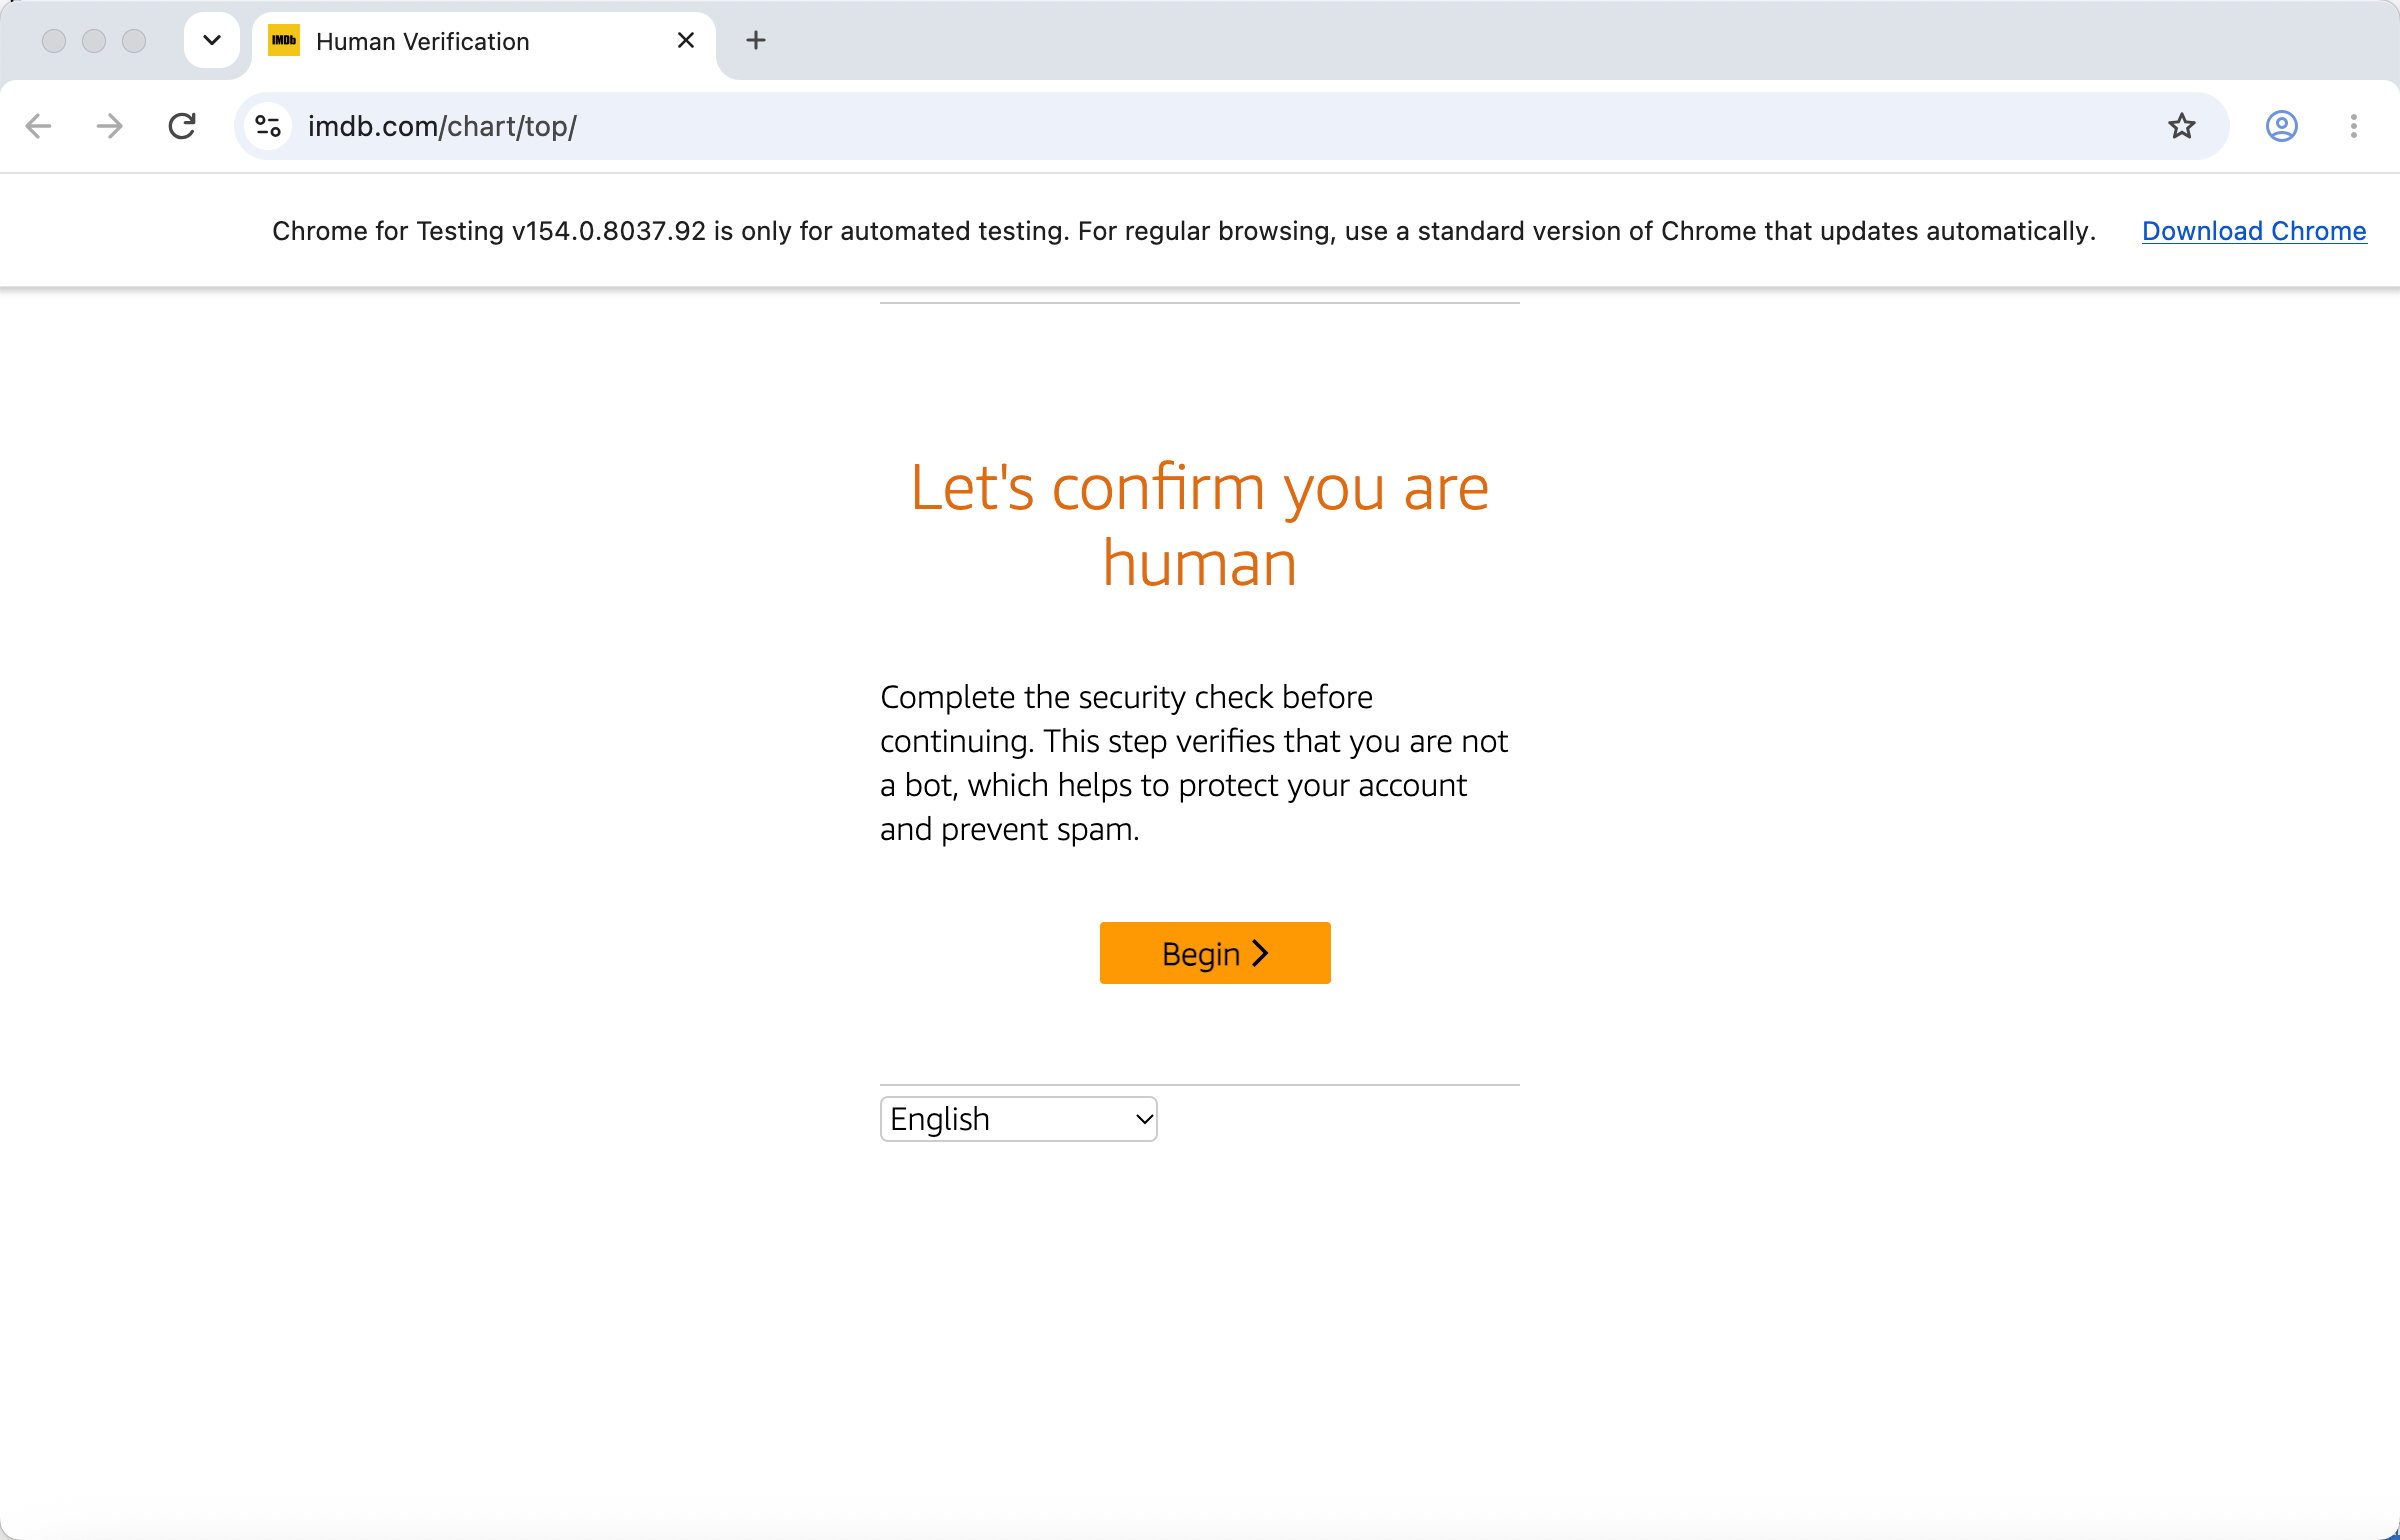

**Need to solve a CAPTCHA manually.** After that the page loaded, but the code still found 0 movies, so the problem was now in my code, not the page.

In [16]:
options = webdriver.ChromeOptions()
options.add_argument("--lang=en-US")
driver = webdriver.Chrome(options=options)

try:
    driver.get("https://www.imdb.com/chart/top/")
    WebDriverWait(driver, 60).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "li.ipc-metadata-list-summary-item"))
    )
    html = driver.page_source
finally:
    driver.quit()

with open("imdb_page.html", "w", encoding="utf-8") as f:
    f.write(html)

soup = BeautifulSoup(html, "html.parser")
print("page title:", soup.title.get_text() if soup.title else None)
print("list items:", len(soup.select("li.ipc-metadata-list-summary-item")))
h3s = [h.get_text() for h in soup.find_all("h3", attrs={"class": "ipc-title__text"})]
print("h3 count:", len(h3s))
print(h3s[:10])

page title: IMDb Top 250 movies
list items: 250
h3 count: 3
['Chart insights', 'More to explore', 'Recently viewed']


**wrong selector.** The page itself is fine: the title is right and there are 250 movie list items. But only 3 elements have the class "ipc-title__text", and they are section headings ("Chart insights", "More to explore", "Recently viewed"), not movie titles. So the selector from online examples (and my first try) is outdated: IMDb has changed its layout. To find where the movie data actually is, I saved the page to `imdb_page.html` and searched it.
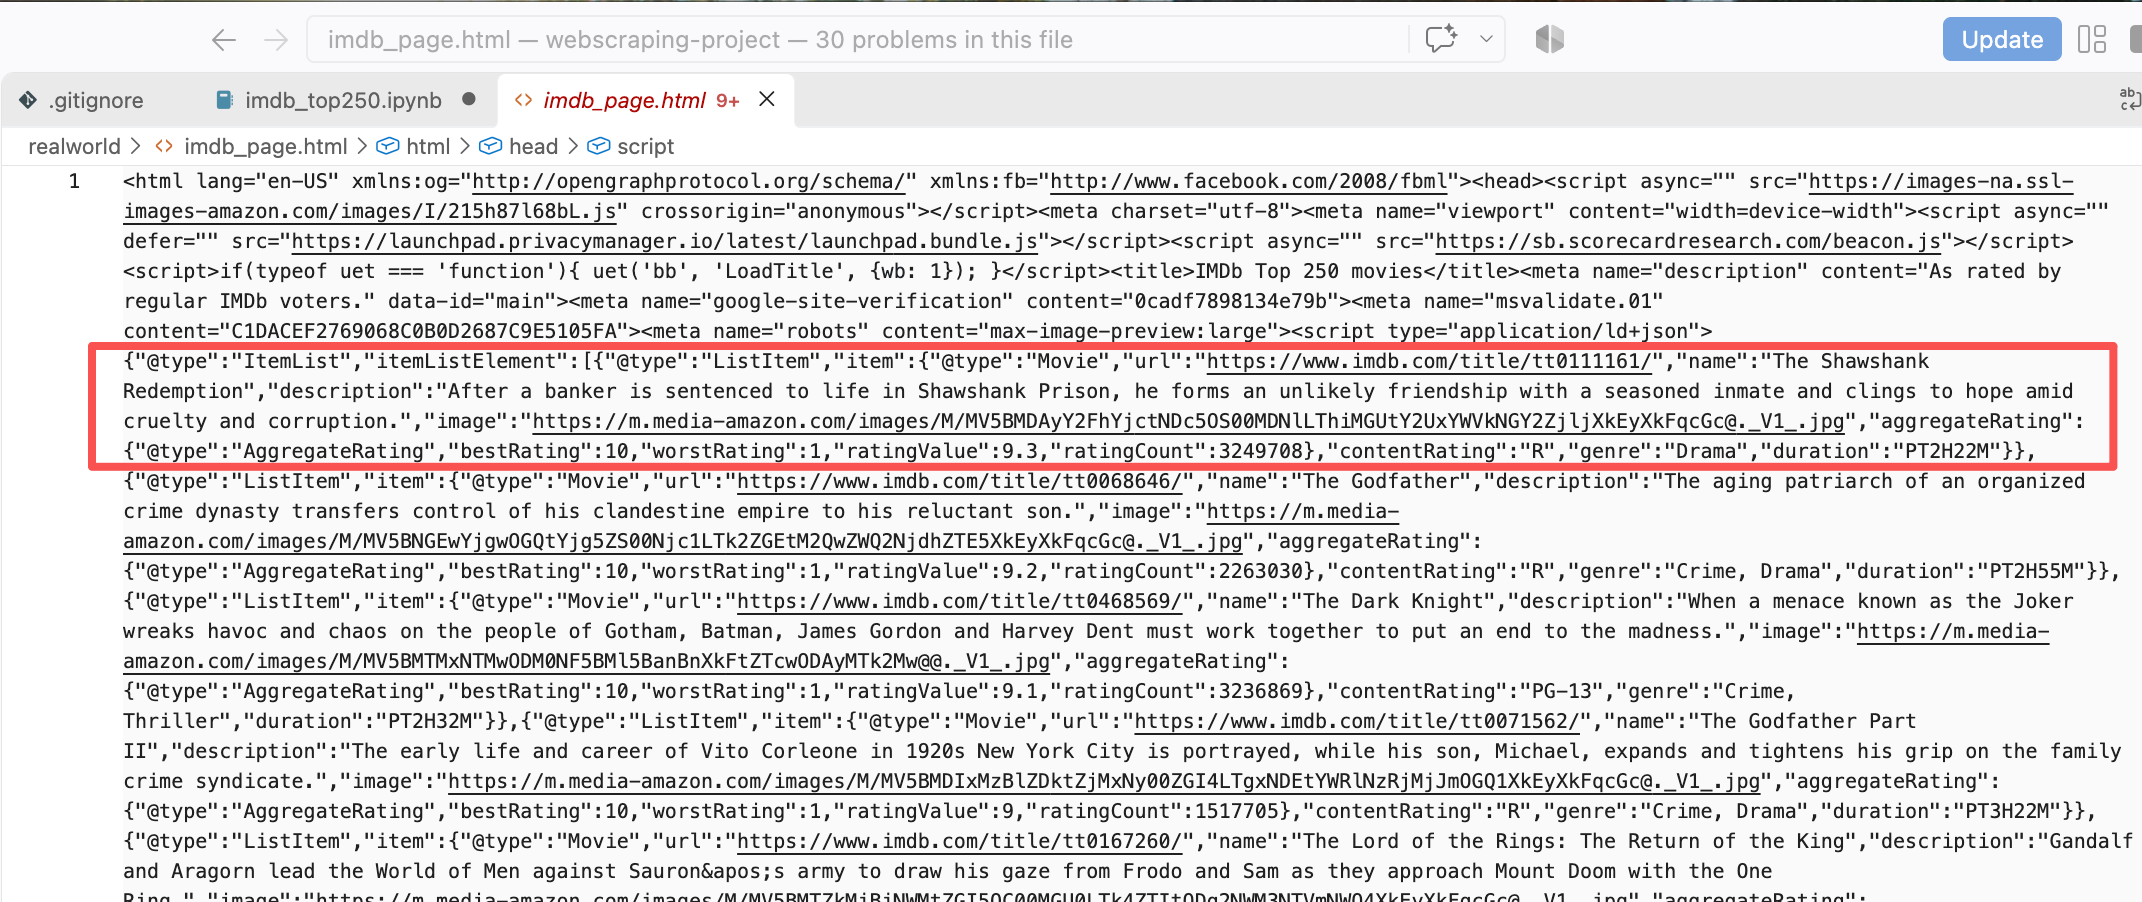

In the saved HTML I found a JSON-LD block that contains all 250 movies with their rating, votes, genre, content rating and duration. I used that instead of the page's class names.

In [17]:
import json, re, html
import pandas as pd

data = json.loads(soup.find("script", type="application/ld+json").string)

def duration_to_minutes(d):
    m = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?", d or "")
    return int(m.group(1) or 0) * 60 + int(m.group(2) or 0) if m and d else None

rows = []
for rank, entry in enumerate(data["itemListElement"], start=1):
    movie = entry["item"]
    rating = movie.get("aggregateRating", {})
    rows.append({
        "rank": rank,
        "title": html.unescape(movie.get("name", "")),
        "rating": rating.get("ratingValue"),
        "votes": rating.get("ratingCount"),
        "genre": movie.get("genre"),
        "content_rating": movie.get("contentRating"),
        "duration_min": duration_to_minutes(movie.get("duration")),
        "url": movie.get("url"),
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(250, 8)


,rank,title,rating,votes,genre,content_rating,duration_min,url
0,1,The Shawshank Redemption,9.3,3249752,Drama,R,142,https://www.imdb.com/title/tt0111161/
1,2,The Godfather,9.2,2263058,"Crime, Drama",R,175,https://www.imdb.com/title/tt0068646/
2,3,The Dark Knight,9.1,3236908,"Crime, Thriller",PG-13,152,https://www.imdb.com/title/tt0468569/
3,4,The Godfather Part II,9.0,1517729,"Crime, Drama",R,202,https://www.imdb.com/title/tt0071562/
4,5,The Lord of the Rings: The Return of the King,9.0,2199238,"Adventure, Drama, Fantasy",PG-13,201,https://www.imdb.com/title/tt0167260/


Reading the JSON is simpler and more stable than guessing class names, and it has more fields. It has no rank field, so I used each movie's position in the list. Durations are in a standard format ("PT2H22M"), which I converted to minutes.

In [18]:
print(df.shape)
print(df.isna().sum())
df.to_csv("imdb_top250.csv", index=False, encoding="utf-8-sig")

(250, 8)
rank              0
title             0
rating            0
votes             0
genre             0
content_rating    7
duration_min      0
url               0
dtype: int64


In [19]:
df[df["content_rating"].isna()][["rank", "title"]]

,rank,title
72,73,12th Fail
79,80,Kimi no na wa.
81,82,Das Boot
91,92,Shingeki no Kyojin: The Last Attack
222,223,Maharaja
246,247,Hababam Sinifi: Sinifta Kaldi
249,250,96


All 6 movies with no content rating are non-US movies, which likely never got a US rating, so I kept them as missing.

In [20]:
print(df.shape)
print(df.isna().sum())
df.to_csv("imdb_top250.csv", index=False, encoding="utf-8-sig")

(250, 8)
rank              0
title             0
rating            0
votes             0
genre             0
content_rating    7
duration_min      0
url               0
dtype: int64


In [21]:
import sqlite3
import pandas as pd

df = pd.read_csv("imdb_top250.csv")
conn = sqlite3.connect("imdb.db")
df.to_sql("top250", conn, if_exists="replace", index=False)
print(pd.read_sql("SELECT COUNT(*) AS n_rows FROM top250", conn))
conn.close()

   n_rows
0     250


# Summary

- **IMDb blocks scrapers.** A normal User-Agent header didn't help. I switched to Selenium to get into the page and still had to solve an image CAPTCHA manually.
- **Outdated selector:** movie titles are no longer in `h3.ipc-title__text`. I found a JSON-LD block with all 250 movies in the saved HTML and parsed it instead.
- **Result:** 250 movies, 8 columns, saved as csv. Saved the final data to a SQLite table